# Import

In [1]:
from PIL import Image
from matplotlib import pyplot as plt
import os

# Original
from noisypatho import BCSS
from noisypatho import utils
from noisypatho import noise


# Read Example Data (BCSS)

In [2]:
# paths
path_he = "./example/he/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"
path_gt = "./example/gt/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"


In [3]:
# open
img_he = Image.open(path_he)
img_gt = Image.open(path_gt)

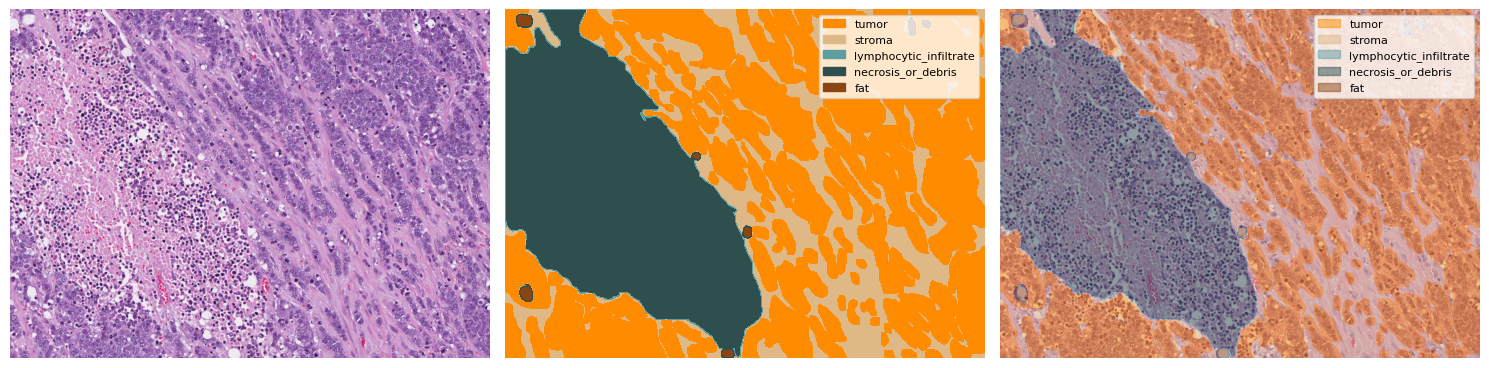

In [4]:
# show
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 20))
ax[0] = utils.ishow(img_he, ax[0])
ax[1] = BCSS.mshow(img_gt, ax[1])
ax[2] = BCSS.overlay(img_he, img_gt, ax[2])
plt.tight_layout()
# save_name = "test.jpg"
# plt.savefig(save_name, dpi=500)
plt.show()


# Binarize (BCSS)

In [2]:
# paths
path_he = "./example/he/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"
path_gt = "./example/gt/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"


In [3]:
# open
img_he = Image.open(path_he)
img_gt = Image.open(path_gt)

In [4]:
# Convert (when necessary)
# The BCSS dataset contains 21 region types. Values 19 and 20 represent
# angioinvasion and DCIS, respectively. You can convert both 19 and 20
# into 1 (tumor).

# converting_values_list = [19, 20]
target_value = 1
# preprocessed = BCSS.convert_mask_a_as_b(img_gt, converting_values_list, target_value)
preprocessed = img_gt  # Comment out this line if you used convert_mask_a_as_b

# Binarize the mask
binarized = BCSS.binarize_mask(preprocessed, target_value)
# binarized.save("./example/mask/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png")


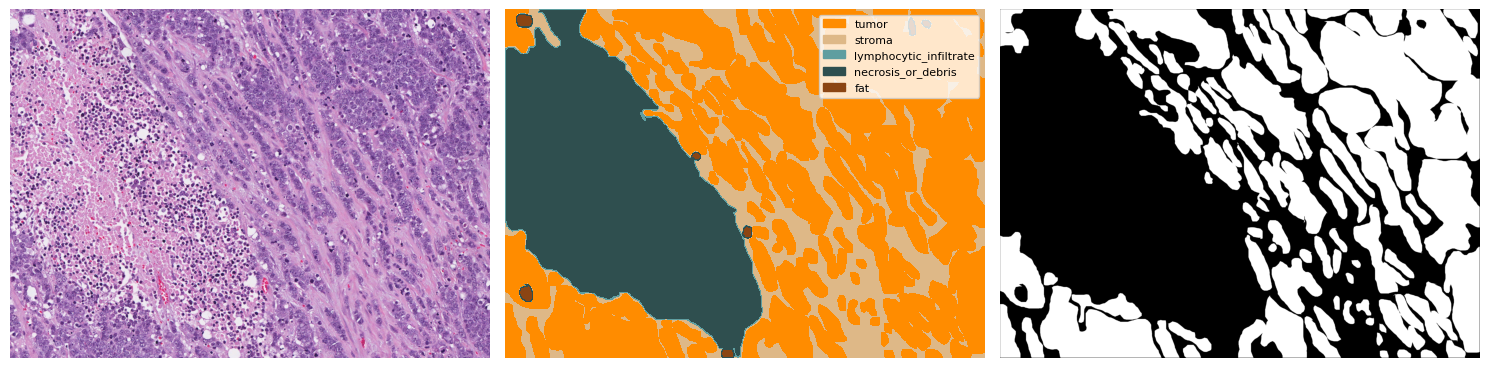

In [5]:
# show
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 20))
ax[0] = utils.ishow(img_he, ax[0])
ax[1] = BCSS.mshow(img_gt, ax[1])
ax[2] = utils.mshow(binarized, ax[2])
plt.tight_layout()
plt.show()


# Make Noisy Label (BCSS)

In [2]:
# Specify paths
# If you have multiple images to process, you can use glob or a CSV file
# to manage all paths.
path_he_list = ["./example/he/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"]
path_mask_list = ["./example/mask/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"]
path_gt_list = ["./example/gt/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"]


In [3]:
# Settings
# noise_level can be 1, 2, or 3 — choose one
noise_level = 3

# noise_types can include: ["dilation", "shrink", "additive", "omission"]
# You can choose one or combine multiple
noise_types = ["dilation"]

num_img = len(path_he_list)
seed = 3

In [4]:
# Create Parameters
params = noise.noise_parameters(num_img, noise_level, noise_types, seed)[0]

In [5]:
for path_he, path_mask, path_gt in zip(path_he_list, path_mask_list, path_gt_list):
    # Open images
    img_he = Image.open(path_he)
    img_mask = Image.open(path_mask)
    img_gt = Image.open(path_gt)

    # Generate noisy label
    result = img_mask
    if "omission" in noise_types:
        result = noise.MAKE_OMISSION_NOISE(result, params, BCSS_mask=img_gt)
    if "dilation" in noise_types:
        result = noise.MAKE_DILATION_NOISE(result, params, BCSS_mask=img_gt)
    if "shrink" in noise_types:
        result = noise.MAKE_SHRINK_NOISE(result, params, BCSS_mask=img_gt)
    if "additive" in noise_types:
        result = noise.MAKE_ADDITIVE_NOISE(result, params, BCSS_mask=img_gt)

    # Save noisy label
    os.makedirs("./example/noisylabel/", exist_ok=True)
    noise_types_name = "-".join(noise_types)
    base_name = os.path.basename(path_he)
    result.save(f"./example/noisylabel/Level{noise_level}_{noise_types_name}_{base_name}.png")


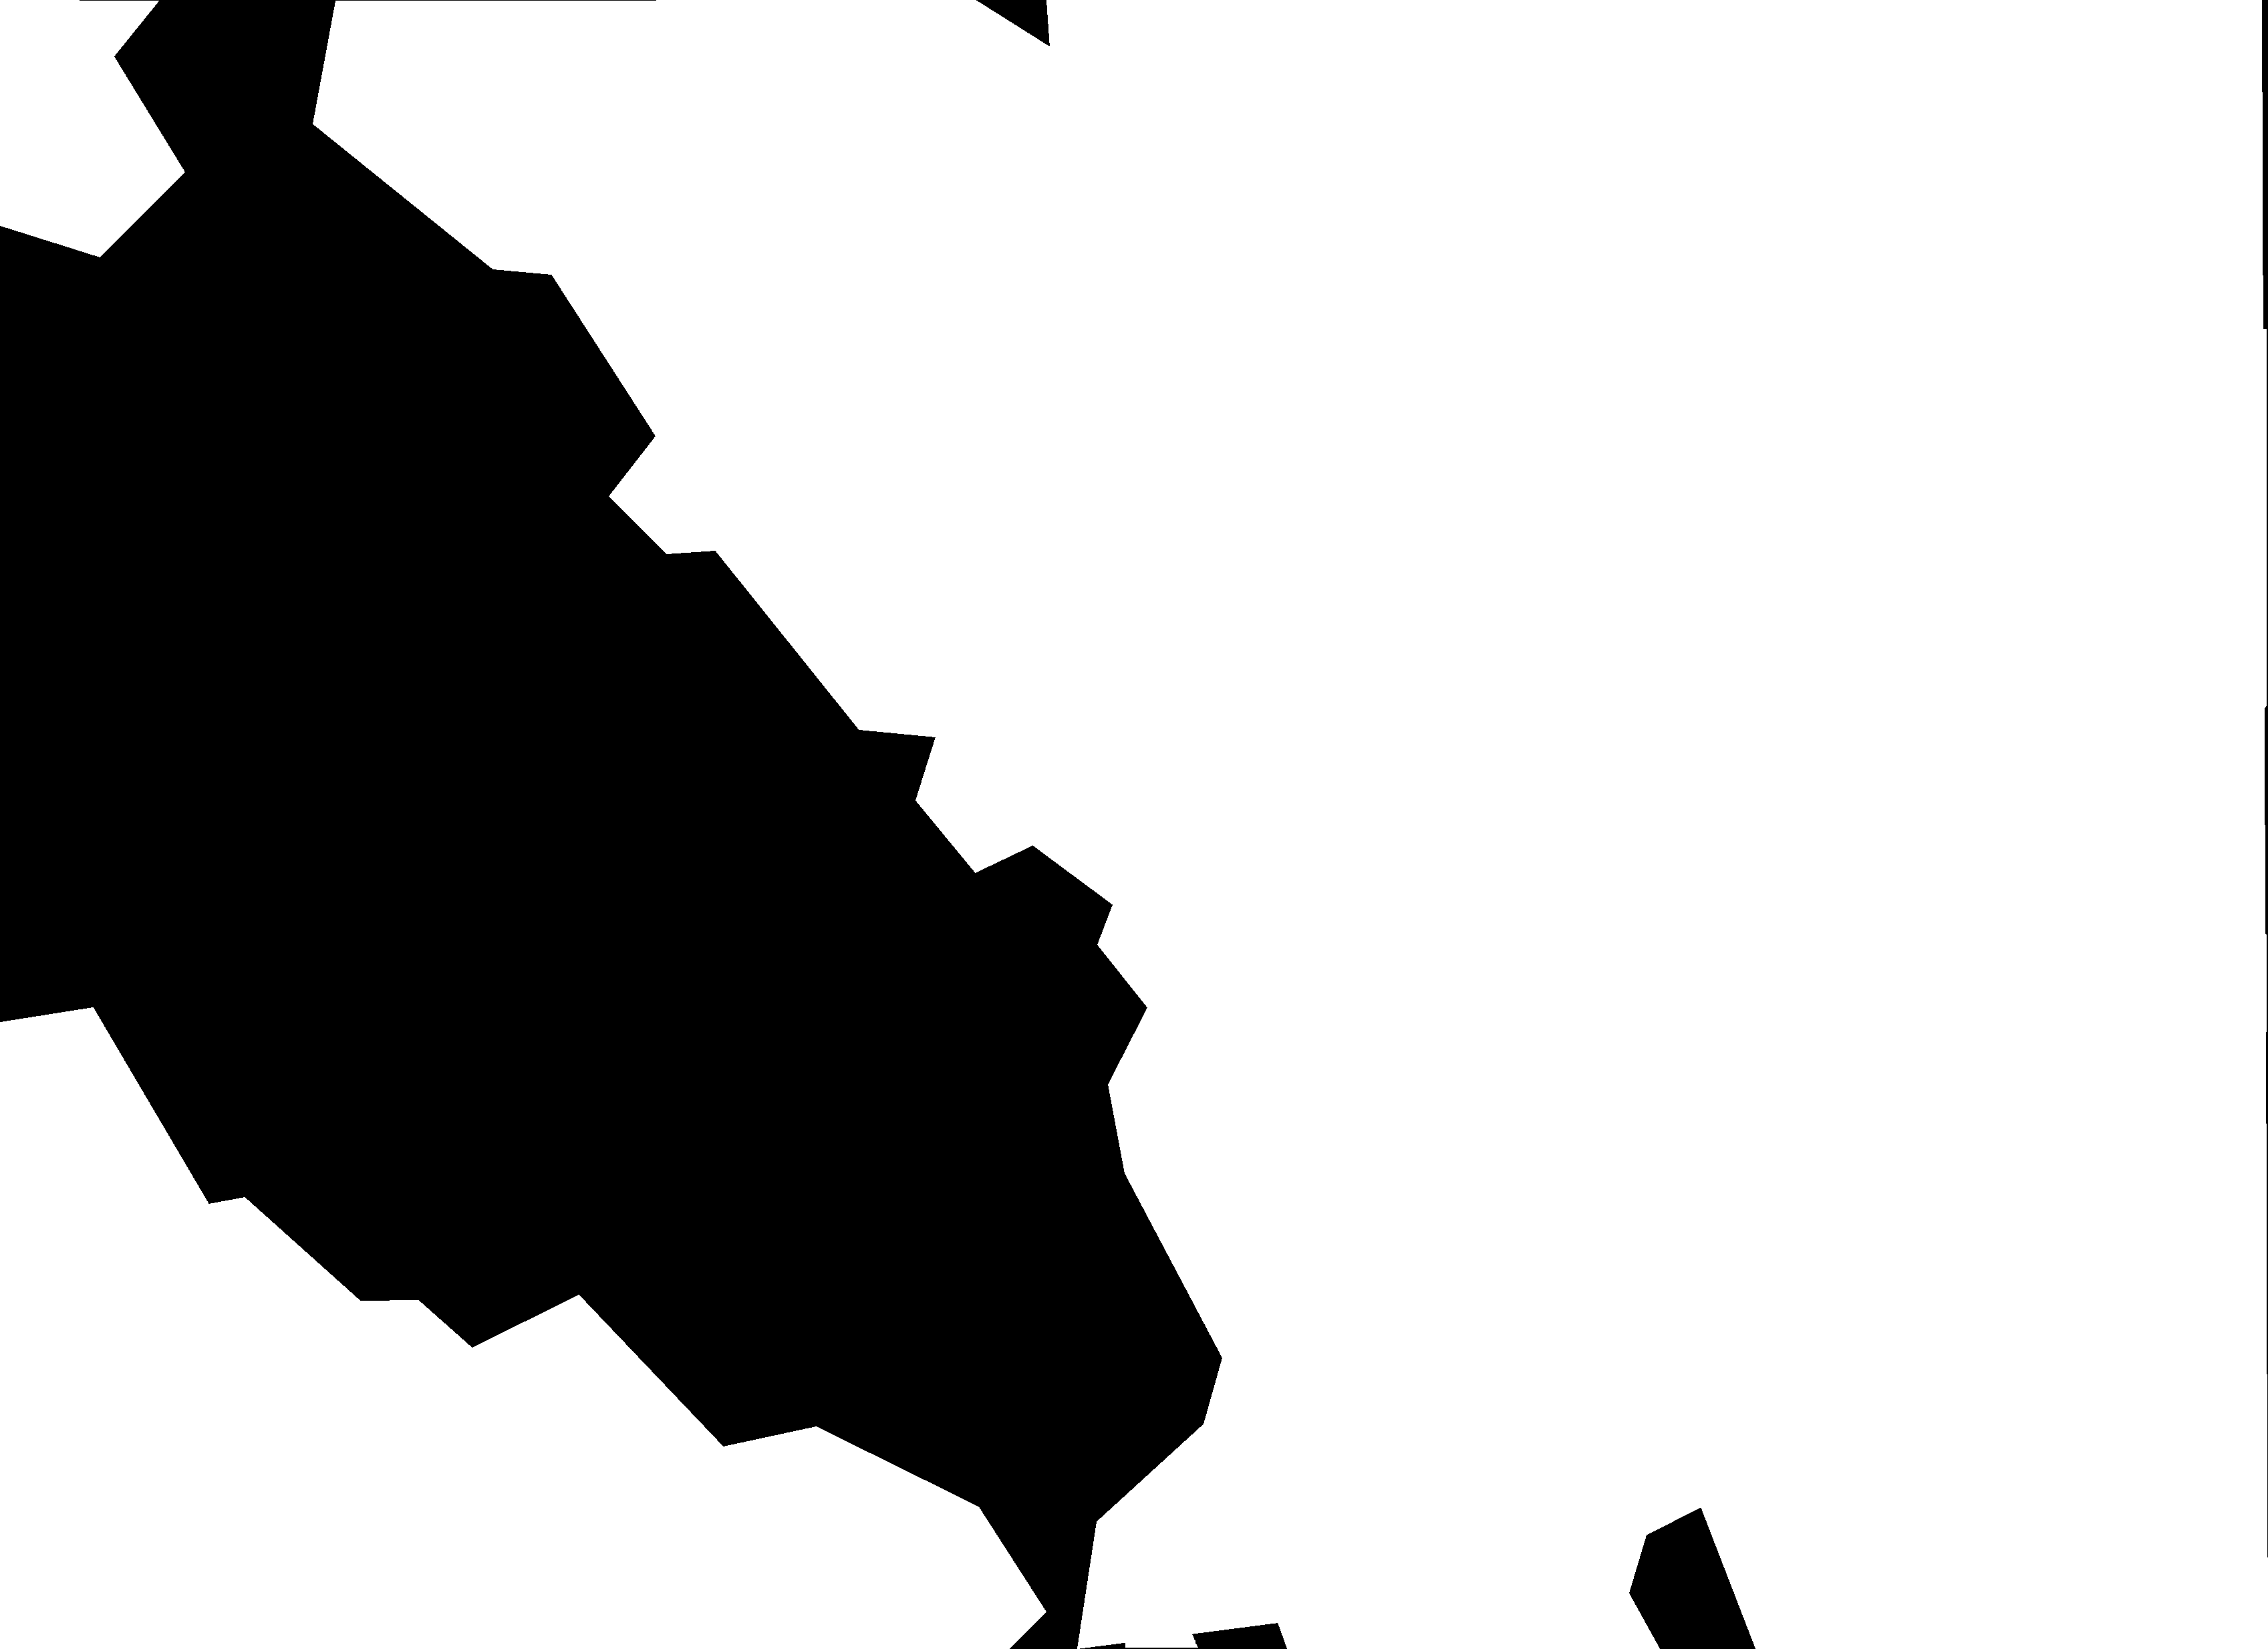

In [6]:
result

# Make Noisy Label (any data)

In [2]:
# Specify paths
# If you have multiple images to process, you can use glob or a CSV file
# to manage all paths.
path_he_list = ["./example/he/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"]
path_mask_list = ["./example/mask/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"]

In [3]:
# Settings
# noise_level can be 1, 2, or 3 — choose one
noise_level = 3

# noise_types can be ["dilation", "shrink", "additive", "omission"]
# You can select one or combine multiple
noise_types = ["dilation"]

num_img = len(path_he_list)
seed = 3

In [4]:
# Create Parameters
params = noise.noise_parameters(num_img, noise_level, noise_types, seed)[0]

In [5]:
for path_he, path_mask in zip(path_he_list, path_mask_list):
    # open
    img_he = Image.open(path_he)
    img_mask = Image.open(path_mask)

    # make noisy label
    result = img_mask
    if "omission" in noise_types:
        result = noise.MAKE_OMISSION_NOISE(result, params)
    if "dilation" in noise_types:
        result = noise.MAKE_DILATION_NOISE(result, params)
    if "shrink" in noise_types:
        result = noise.MAKE_SHRINK_NOISE(result, params)
    if "additive" in noise_types:
        result = noise.MAKE_ADDITIVE_NOISE(result, params)

    # save
    # os.makedirs("./example/noisylabel/", exist_ok=True)
    # noise_types_name = "-".join(noise_types)
    # base_name = os.path.basename(path_he)
    # result.save(f"./example/noisylabel/Level{noise_level}_{noise_types_name}_{base_name}.jpg")

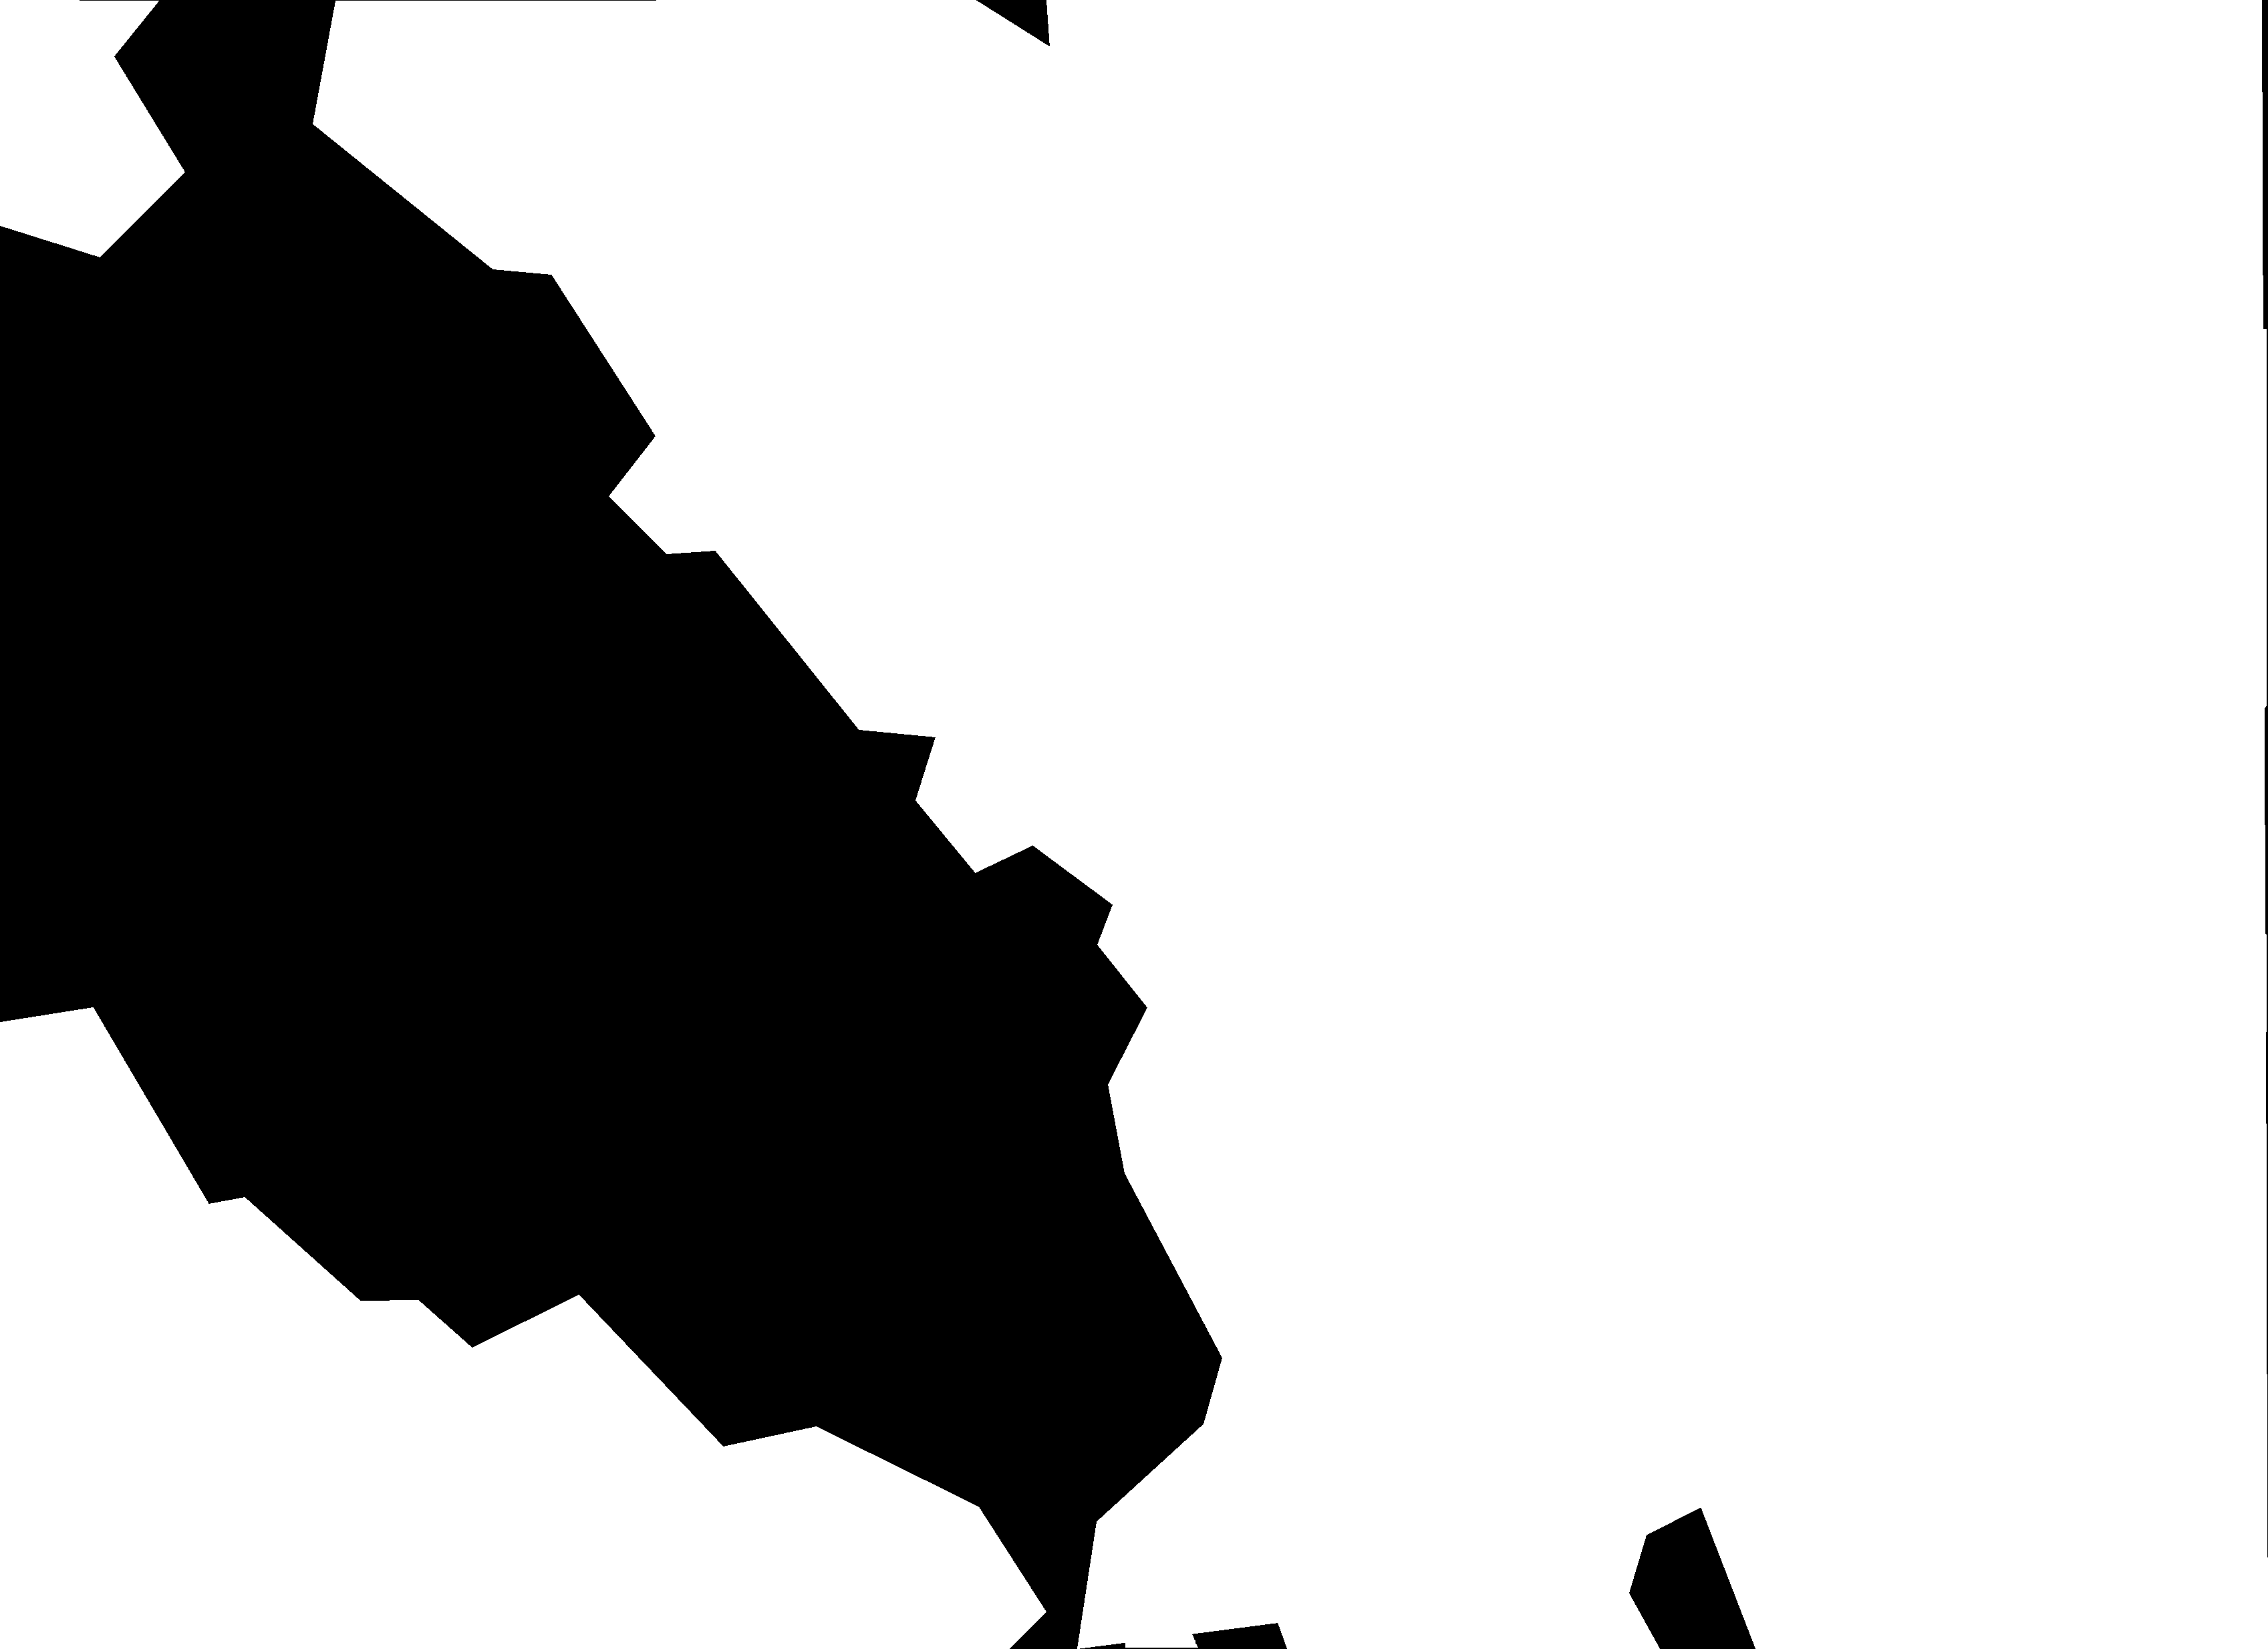

In [6]:
result

# check difference

In [2]:
# Specify paths
path_he = "./example/he/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"
path_mask = "./example/mask/TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png"
path_noisymask = "./example/noisylabel/Level3_dilation_TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png.png"


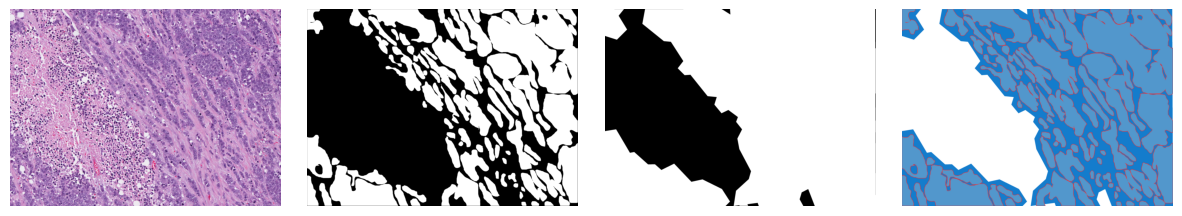

In [3]:
# Load images
img_he = Image.open(path_he)
img_mask = Image.open(path_mask)
img_noisymask = Image.open(path_noisymask)

# Compare original mask and noisy mask
noise.see_diff(img_he, img_mask, img_noisymask, figsize=(15,10))